<a href="https://colab.research.google.com/github/evacragnolino/Data-Science-Foundations/blob/main/Eva_C_Unit_7_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What affects education?

My data set has measures of elementry performance in Math, Science and Reading across. It also has corresponding net worth and debt data for each state and funding enrollment and per pupil spending for schools and each state and across reporting areas.

In [1]:
!pip install preliz
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.9/513.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.6/171.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.5 MB/s eta 0:00:00
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb
import preliz as pz

In [3]:
edu = pd.read_csv('https://raw.githubusercontent.com/evacragnolino/Data-Science-Foundations/main/unit%207%20data%20-%20Sheet1%20(1).csv')

In [4]:
# Drop the first row which seems to be an aggregate 'Reporting Areas...'
edu = edu.iloc[1:].copy()

# Drop irrelevant 'Unnamed' columns
edu = edu.drop(columns=['Unnamed: 1', 'Unnamed: 8', 'Unnamed: 16'])

# List of columns that should be numeric but are currently objects
numeric_cols_to_clean = [
    'total', 'From federal', 'From state', 'From local', 'Current', 'Capital',
    'current spending', 'Fall enrollment', 'science', 'Net Worth',
    'Net Worth (Excluding Equity in Own Home)', 'Equity in Own Home',
    'Equity in Motor Vehicles', 'Retirement accounts', 'Total Debt',
    'Secured Debt', 'Unsecured Debt', 'Credit Card Debt'
]

# Clean and convert these columns to numeric
for col in numeric_cols_to_clean:
    if col in edu.columns and edu[col].dtype == 'object':
        edu[col] = edu[col].str.replace(',', '', regex=False) # Remove commas
        edu[col] = pd.to_numeric(edu[col], errors='coerce') # Convert to numeric, coercing errors to NaN

edu.info()
edu.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 1 to 36
Data columns (total 21 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   gegraphic area                            36 non-null     object 
 1   total                                     36 non-null     int64  
 2   From federal                              36 non-null     int64  
 3   From state                                36 non-null     int64  
 4   From local                                36 non-null     int64  
 5   Current                                   36 non-null     int64  
 6   Capital                                   36 non-null     int64  
 7   current spending                          36 non-null     int64  
 8   Fall enrollment                           36 non-null     int64  
 9   Math                                      36 non-null     int64  
 10  reading                                 

,gegraphic area,total,From federal,From state,From local,Current,Capital,current spending,Fall enrollment,Math,...,science,Net Worth,Net Worth (Excluding Equity in Own Home),Equity in Own Home,Equity in Motor Vehicles,Retirement accounts,Total Debt,Secured Debt,Unsecured Debt,Credit Card Debt
1,Arizona….........................................,13858937,2502145,6553906,4802886,10901568,1854564,12003,884915,232,...,149.0,204300.0,57750.0,263000.0,13660.0,69500.0,148000.0,180000.0,15000.0,6500.0
2,Arkansas…........................................,7274695,1066301,5044052,1164342,6391997,953854,13873,458186,230,...,150.0,62500.0,20010.0,95000.0,12620.0,54490.0,39000.0,80000.0,8000.0,6000.0
3,California…......................................,135520606,16063644,71002818,48454144,109219533,14548384,20233,5274265,233,...,140.0,273800.0,73700.0,550000.0,15000.0,100000.0,86200.0,206200.0,9600.0,4800.0
4,Colorado…........................................,16594912,1394604,6109989,9090319,13492171,2140745,15897,840727,239,...,NaN,370000.0,84510.0,350000.0,15970.0,100000.0,121100.0,215000.0,9300.0,4079.0
5,Delaware…........................................,2904663,312117,1668554,923992,2753108,223487,22201,123393,233,...,150.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


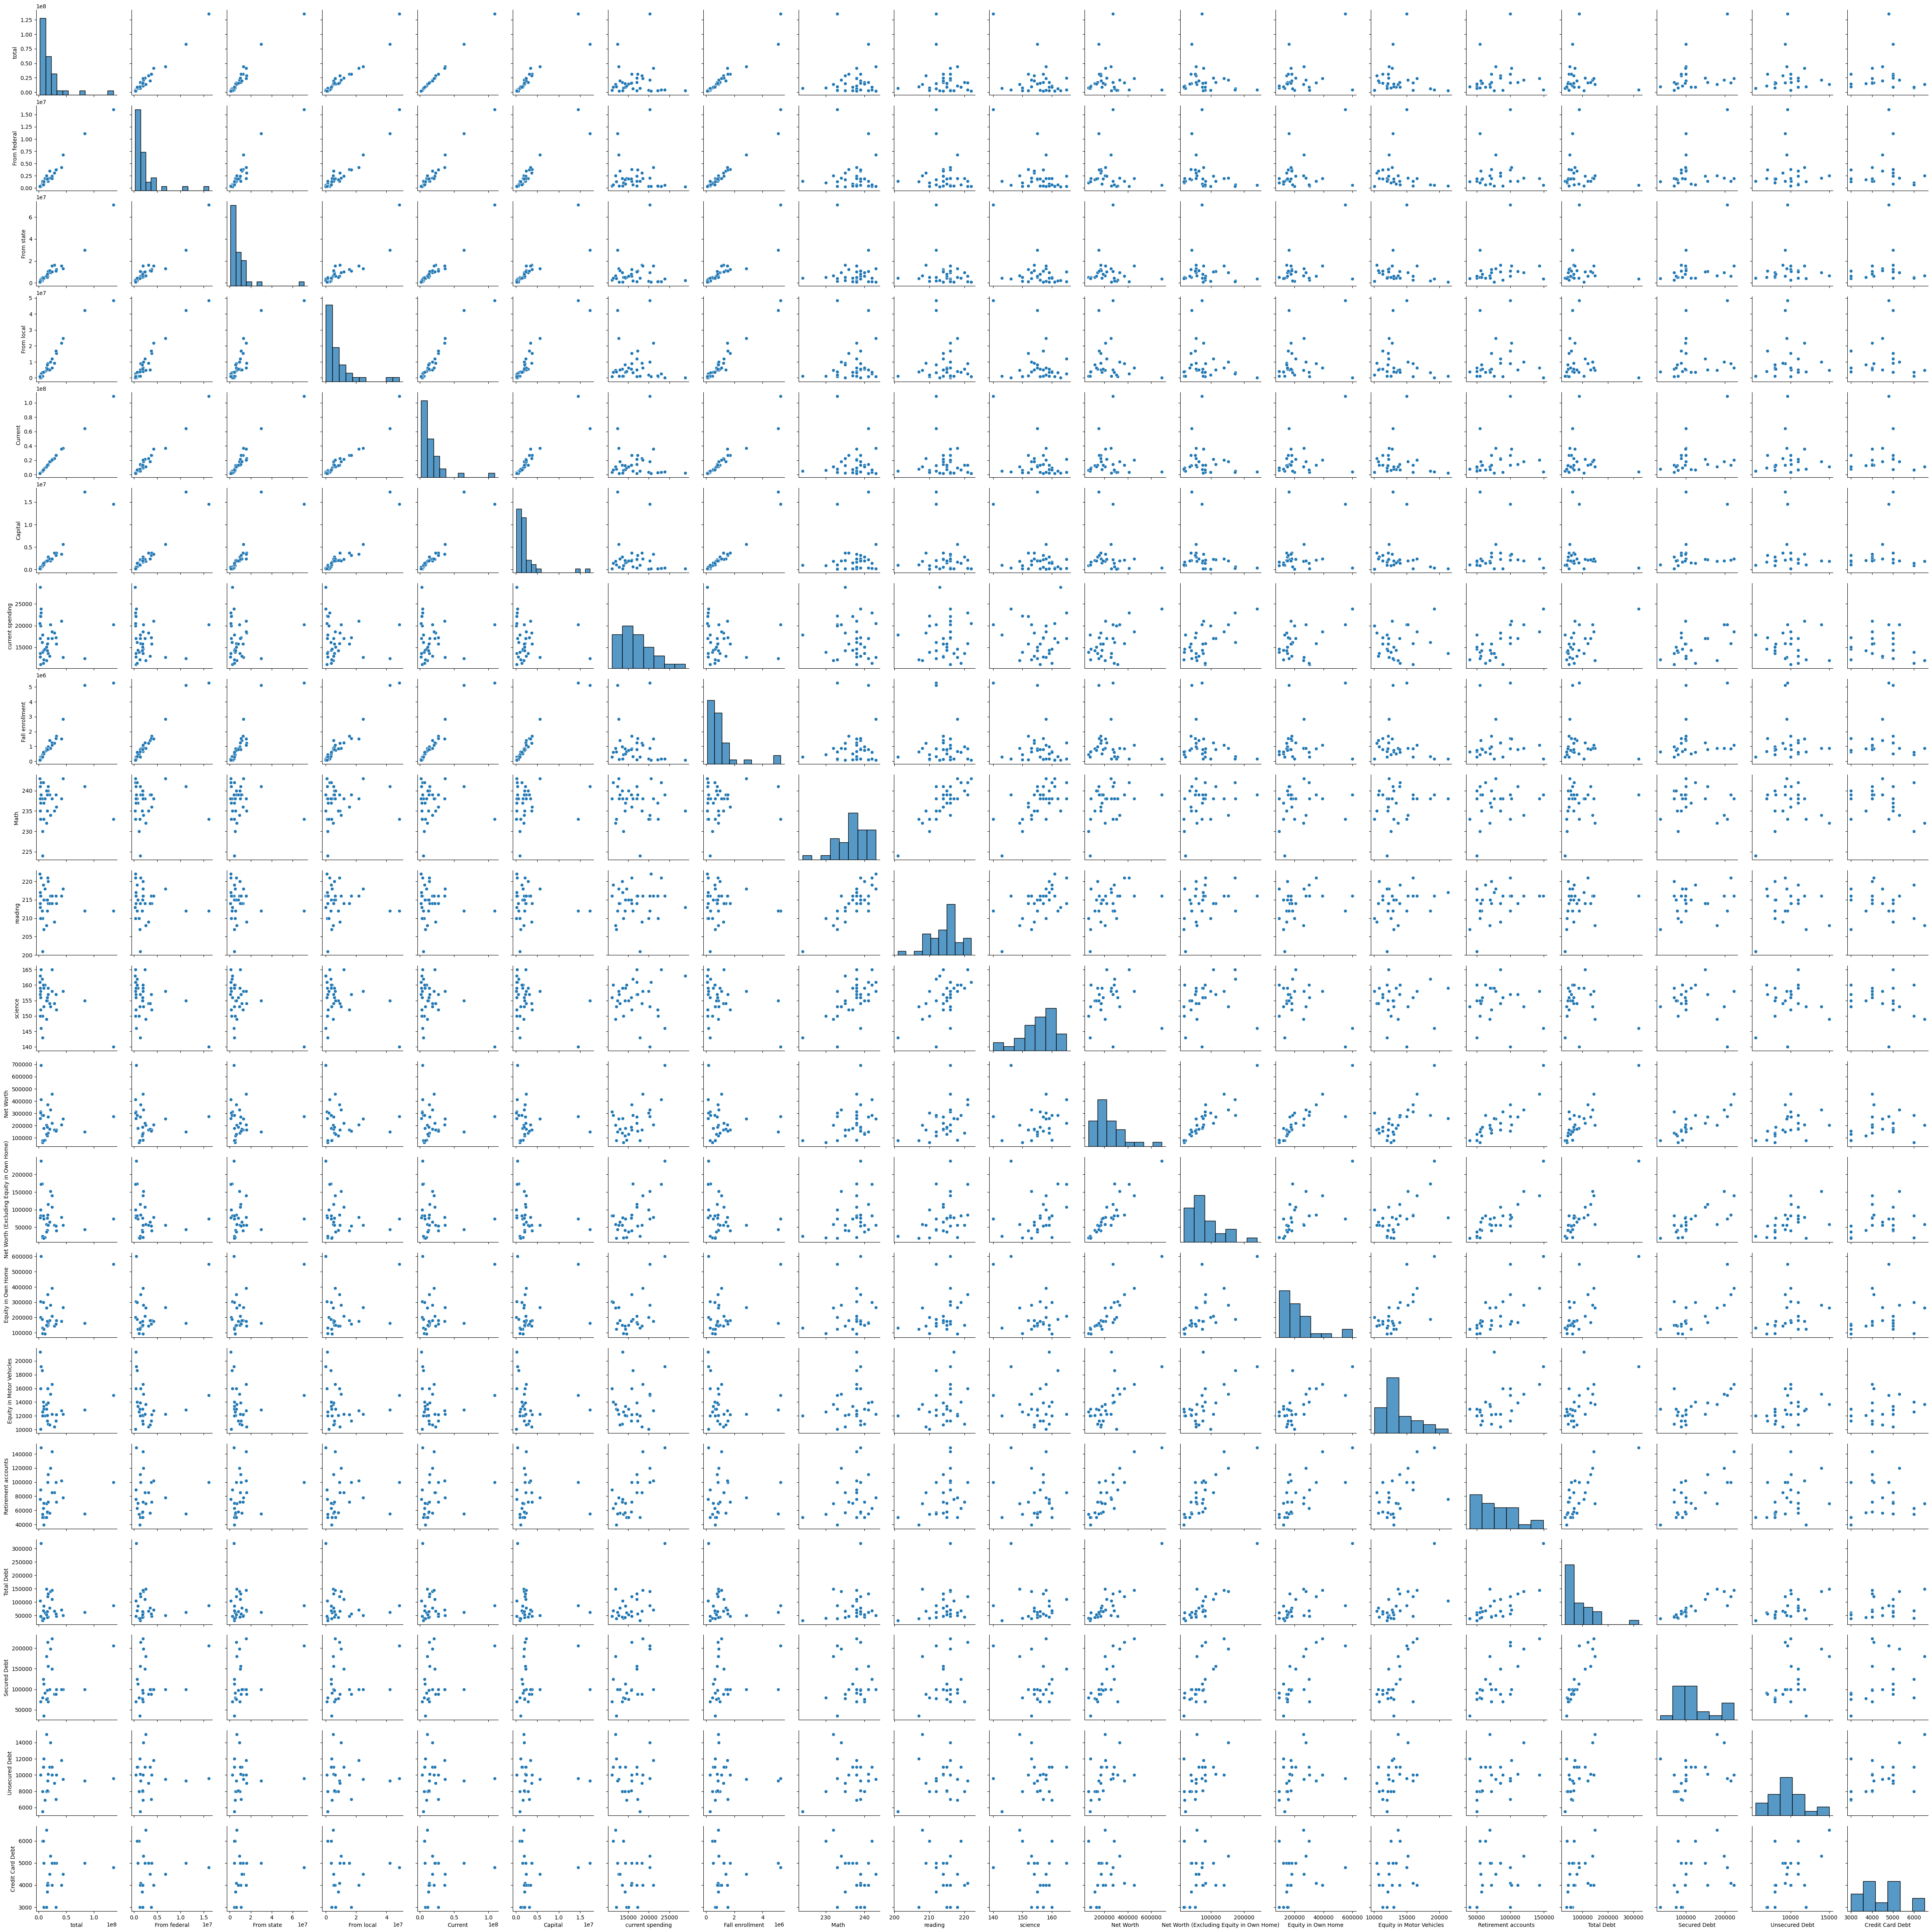

In [5]:
sns.pairplot(edu)

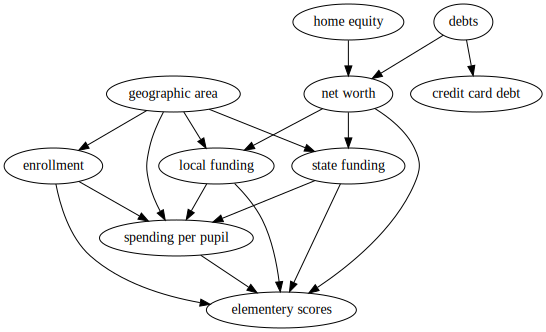

In [6]:
dag_b = gv.Digraph(comment='education_dag')

dag_b.node('G', 'geographic area')
dag_b.node('E','enrollment')
dag_b.node('S','state funding')
dag_b.node('L', 'local funding')
dag_b.node('H','home equity')
dag_b.node('P','spending per pupil')
dag_b.node('N', 'net worth')
dag_b.node('D','debts')
dag_b.node('W','elementery scores')
dag_b.node('C','credit card debt')

dag_b.edges(['GE', 'GS','GL','GP','HN','DN','DC','NL','NS','NW','EP','SP','LP','PW','EW','SW','LW'])

dag_b


In [ ]:
# Rename 'current spending' column to 'current_spending' to remove space for easier use in formula
edu = edu.rename(columns={'current spending': 'current_spending'})

# Now create the model using the renamed column without Q()
model_poly_4 = bmb.Model("reading ~ poly(current_spending, degree=4)", edu, family="negativebinomial")
idata_poly_4 = model_poly_4.fit()

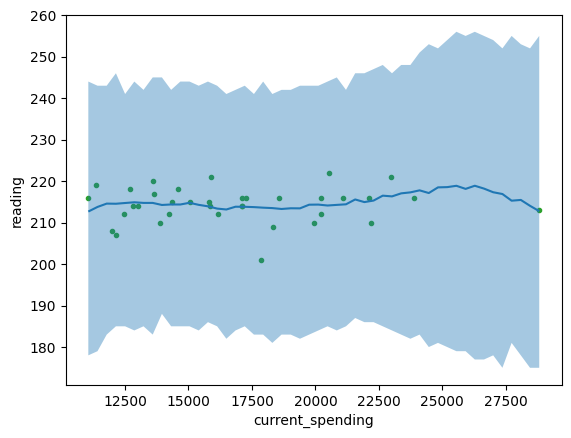

In [8]:
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "current_spending", pps=True)
#raw data
plt.plot(edu.current_spending, edu.reading, "C2.", zorder=-3)

In [ ]:
edu = edu.rename(columns={'current spending': 'current_spending'})

# Now create the model using the renamed column without Q()
model_poly_2 = bmb.Model("reading ~ poly(current_spending, degree=2)", edu, family="negativebinomial")
idata_poly_2 = model_poly_2.fit()

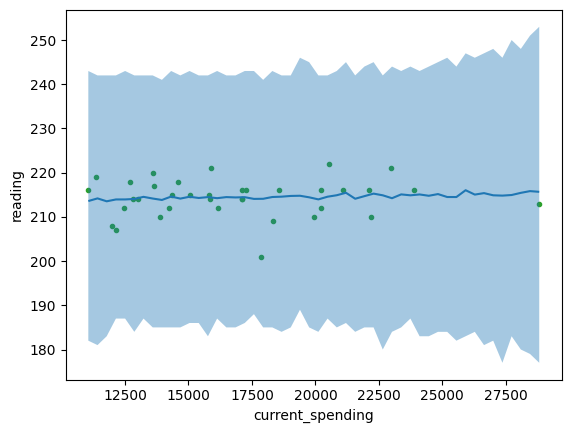

In [10]:
bmb.interpret.plot_predictions(model_poly_2, idata_poly_2, "current_spending", pps=True)
#raw data
plt.plot(edu.current_spending, edu.reading, "C2.", zorder=-3)

In [ ]:
edu = edu.rename(columns={'Net Worth': 'net_worth'})

# Drop rows where 'net_worth' is NaN before creating the model
edu_cleaned = edu.dropna(subset=['net_worth']).copy()

# Now create the model using the cleaned data
model_poly_2n = bmb.Model("reading ~ poly(net_worth, degree=2)", edu_cleaned, family="negativebinomial")
idata_poly_2n = model_poly_2.fit()

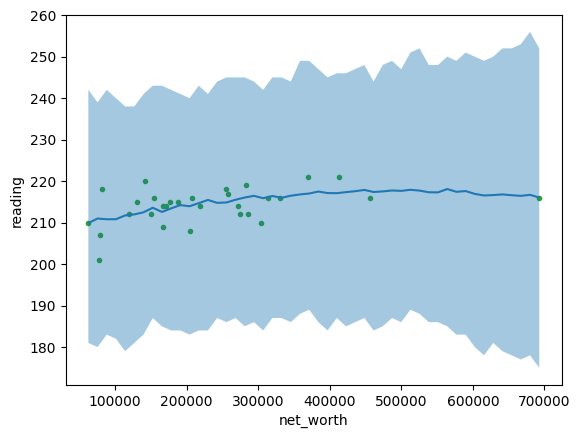

In [24]:
bmb.interpret.plot_predictions(model_poly_2n, idata_poly_2n, "net_worth", pps=True)
#raw data
plt.plot(edu.net_worth, edu.reading, "C2.", zorder=-3)

In [16]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [17]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 24], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 8.0


In [ ]:
current_spending = edu['current_spending'].values
reading = edu['reading'].values

with pm.Model() as model_edugp:
    #prior for our smoothness parameter
    ℓ = pm.InverseGamma('ℓ', **get_ig_params(current_spending))

    #this is our kernal, which decides how our points relate to one another
    cov = pm.gp.cov.ExpQuad(1, ls=ℓ)
    #this specfices that we're using an HSGP
    gp = pm.gp.HSGP(m=[168], c=8.0, cov_func=cov)

    #f is for function, as in the function we use to transform our data
    f = gp.prior('f', X=current_spending[:, None]) # Reshape to 2D array
    #prior for the neg binomial
    α = pm.HalfNormal('α', 1)
    #likelihood
    y = pm.NegativeBinomial("y", np.exp(f), α, observed=reading)

    idata_edugp = pm.sample(target_accept=0.95, tune=2000, draws=3000)

In [27]:
bmb.interpret.plot_predictions(model_edugp, idata_edugp, "net_worth", pps=True)
#raw data
plt.plot(edu.net_worth, edu.reading, "C2.", zorder=-3)

AttributeError: 'Model' object has no attribute 'data'